In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.utils import resample

In [2]:
df = pd.read_csv("../data/processed/train_ohe.csv")
df

,amt,city_pop,is_fraud,hour,age,distance,mean_amt,amt_std,distance_from_prev,time_since_prev_transaction_hours,...,state_WA,state_WI,state_WV,state_WY,week_day_Monday,week_day_Saturday,week_day_Sunday,week_day_Thursday,week_day_Tuesday,week_day_Wednesday
0,7.27,1645,0,12,33,127.606419,56.023366,122.632635,0.000000,0.083333,...,False,False,False,True,False,False,False,False,True,False
1,52.94,1645,0,8,33,110.309077,56.023366,122.632635,224.769536,19.961667,...,False,False,False,True,False,False,False,False,False,True
2,82.08,1645,0,8,33,21.787292,56.023366,122.632635,105.220587,0.044167,...,False,False,False,True,False,False,False,False,False,True
3,34.79,1645,0,12,33,87.204338,56.023366,122.632635,88.152407,3.843889,...,False,False,False,True,False,False,False,False,False,True
4,27.18,1645,0,13,33,74.213070,56.023366,122.632635,132.876960,0.542222,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,60.47,532,0,21,64,78.492673,67.843832,157.223610,72.134080,8.538889,...,False,False,False,False,False,True,False,False,False,False
1296671,74.29,532,0,0,64,55.400846,67.843832,157.223610,50.128303,3.600556,...,False,False,False,False,False,False,True,False,False,False
1296672,246.56,532,0,2,64,115.674563,67.843832,157.223610,94.204046,2.116111,...,False,False,False,False,False,False,True,False,False,False
1296673,2.62,532,0,8,64,60.513482,67.843832,157.223610,61.101300,5.274722,...,False,False,False,False,False,False,True,False,False,False


In [3]:
def get_num_columns(df):
       dtypes_df = pd.DataFrame(df.dtypes).reset_index()
       num_cols = list(dtypes_df[dtypes_df[0] != bool]["index"].values)
       return num_cols

num_cols = get_num_columns(df)
num_cols.remove("is_fraud")

In [4]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

df = None
del df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
print(X_train.shape, y_train.shape)

(1037340, 81) (1037340,)


In [5]:
scaler = RobustScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])


In [6]:
X_train

,amt,city_pop,hour,age,distance,mean_amt,amt_std,distance_from_prev,time_since_prev_transaction_hours,speed_capped,...,state_WA,state_WI,state_WV,state_WY,week_day_Monday,week_day_Saturday,week_day_Sunday,week_day_Thursday,week_day_Tuesday,week_day_Wednesday
986070,0.186113,0.700894,-1.000000,-0.041667,-1.178369,0.976103,0.674859,0.144603,0.268948,-0.085362,...,False,False,True,False,False,False,False,True,False,False
671891,-0.222873,8.614450,0.166667,0.541667,0.985093,0.031409,0.125891,0.259142,5.429543,-0.348984,...,False,False,False,False,False,True,False,False,False,False
507675,-0.442478,0.019403,0.416667,-0.416667,-0.335018,0.219272,3.014155,-0.983476,-0.269679,-0.133975,...,False,False,False,False,False,False,False,False,True,False
62932,0.329340,-0.049834,0.250000,0.041667,-0.072638,1.549556,-0.224208,-0.914355,0.072113,-0.272676,...,False,False,False,False,True,False,False,False,False,False
752379,0.182845,0.068879,0.250000,1.041667,0.486172,0.587088,2.860824,-0.494330,0.817809,-0.290345,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581583,0.443159,-0.018330,0.500000,-0.500000,0.220654,1.246665,-0.884083,-1.105835,0.064218,-0.325178,...,False,False,False,False,False,False,False,False,True,False
285808,-0.082914,0.065050,0.416667,-0.666667,0.706436,0.033030,-0.073192,-0.123490,7.483481,-0.367231,...,False,False,False,False,False,False,False,True,False,False
349917,-0.551804,2.646464,-0.083333,0.125000,0.033310,1.068884,0.314766,0.528852,0.152678,0.064115,...,False,False,False,False,False,False,False,True,False,False
1066078,-0.264261,3.774674,-0.083333,-0.416667,0.715415,0.207339,8.453901,0.611681,-0.125862,0.454230,...,False,False,False,False,False,True,False,False,False,False


In [7]:
from sklearn.model_selection import GridSearchCV


model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=4)
param_grid = {
    "C":[0.01, 0.1, 1, 10],
    "class_weight":["balanced"],
    "solver": ["lbfgs"]
}
grid = GridSearchCV(model,
                    param_grid,
                    scoring="average_precision",
                    cv=5,
                    n_jobs=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

In [8]:
results = pd.DataFrame(grid.cv_results_)
print(results[["params", "mean_test_score"]])

                                              params  mean_test_score
0  {'C': 0.01, 'class_weight': 'balanced', 'solve...         0.217677
1  {'C': 0.1, 'class_weight': 'balanced', 'solver...         0.211575
2  {'C': 1, 'class_weight': 'balanced', 'solver':...         0.210542
3  {'C': 10, 'class_weight': 'balanced', 'solver'...         0.210845


In [9]:
def get_scores(model, X_test, y_test, target_precision=0.9):
    try:
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    except:
        y_pred_prob = model.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    

    # find indices where precision >= target
    valid_idx = np.where(precision >= target_precision)[0]

    if len(valid_idx) > 0:
        best_recall = recall[valid_idx].max()
    else:
        best_recall = 0.0

    print(f"roc_auc: {roc_auc}, pr_auc: {pr_auc}, best_recall: {best_recall}")
    return roc_auc, pr_auc, best_recall, precision, recall


def draw_confusion_matrix(model, X_test,threshold=0.8):
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    except:
        y_pred_proba = model.decision_function(X_test)
    y_pred = (y_pred_proba >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()
    

In [13]:
model = best_model
roc_auc, pr_auc, best_recall, precision, recall = get_scores(model, X_test, y_test, target_precision=0.5)


roc_auc: 0.9286350734825861, pr_auc: 0.22083297571917251, best_recall: 0.0


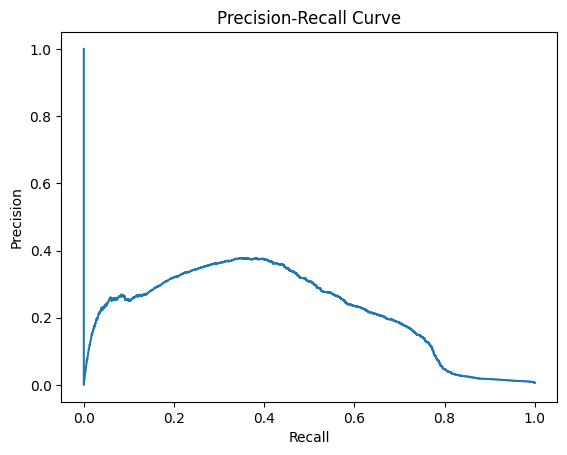

In [14]:

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

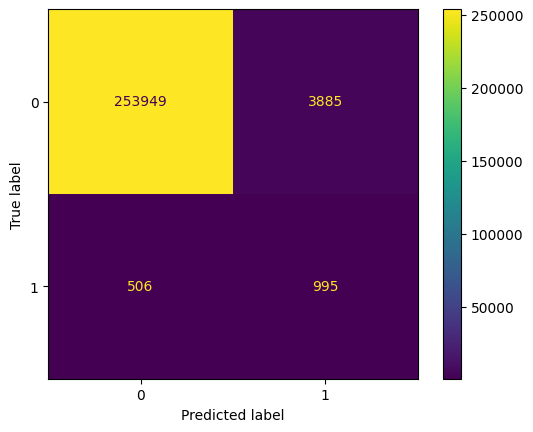

In [12]:
draw_confusion_matrix(model, X_test)

0.2044632997897633
